# Fase B — Entrenamiento del modelo CIL (Conditional Imitation Learning)

Behavioral Cloning **condicionado por comandos de navegación**, según Codevilla
et al. (CLIymodelos.pdf). Backbone convolucional estilo **PilotNet / Bojarski**
compartido, y una **rama (branch) por comando**; el comando activo selecciona la
rama cuya salida es el ángulo de dirección.

- Entrada: imagen de la cámara a bordo + comando de navegación (one-hot).
- Salida: `steering` (un escalar). **La velocidad NO se entrena** (es constante).
- Comandos: `2=FOLLOW`, `3=LEFT`, `4=RIGHT` (**3 ramas**). El comando
  `5=STRAIGHT` no tiene rama propia: en una ciudad con líneas de carril, "cruzar
  derecho" se comporta igual que seguir el carril, así que el controlador de
  inferencia **enruta STRAIGHT a FOLLOW**.

> Las etiquetas de comando provienen de `training/relabel_from_gps.py`, que las
> deriva de la geometría real de la trayectoria GPS (las anotadas con el teclado
> durante la conducción quedaron mal). El steering es el humano, sin tocar.

> Recomendado: ejecutar en **Google Colab (GPU)** o en un venv con **Python
> 3.11/3.12 + TensorFlow**. TensorFlow aún no publica wheels para Python 3.14.

## 1. Dependencias

In [1]:
# En Colab normalmente ya están. En local:
# pip install tensorflow opencv-python pandas scikit-learn matplotlib
import sys, os, json, math, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

I0000 00:00:1782795910.804216  612678 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782795910.834906  612678 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782795911.539698  612678 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0 | Keras 3.15.0
GPU: []


E0000 00:00:1782795912.040065  612678 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782795912.040253  612783 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782795912.066455  612678 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Configuración (rutas, comandos, hiperparámetros)

In [ ]:
# Dataset fisico AUMENTADO y BALANCEADO (~70k, 23.333 por comando). El flip y el
# shift ya estan HORNEADOS en las imagenes (augmentacion offline), por eso aca no
# se vuelven a aplicar. Se localiza relativo al repo para que funcione tras
# `git clone` en Colab: busca driving_log_augmented.csv desde el directorio actual.
import glob
def _find_dataset_csv():
    # Hacia ABAJO desde el cwd (Colab: `git clone` deja el repo bajo /content).
    hits = glob.glob(os.path.join(os.getcwd(), "**", "driving_log_augmented.csv"),
                     recursive=True)
    if hits:
        return hits[0]
    # Hacia ARRIBA desde el cwd (libreta abierta dentro de training/).
    d = os.getcwd()
    for _ in range(6):
        cand = os.path.join(d, "dataset", "driving_log_augmented.csv")
        if os.path.exists(cand):
            return cand
        d = os.path.dirname(d)
    return None

CSV_PATH = _find_dataset_csv()
assert CSV_PATH, ("No encuentro driving_log_augmented.csv. Cloná el repo o corré "
                  "la libreta dentro del proyecto.")
DATASET_DIR = os.path.dirname(CSV_PATH)

print("DATASET_DIR =", DATASET_DIR)
print("CSV_PATH =", CSV_PATH)

# La camara entrega 320x160. Recortamos el cielo (arriba) y un poco abajo, y
# redimensionamos a la entrada del modelo (estilo Codevilla 200x88).
CROP_TOP    = 55      # px recortados arriba (cielo / horizonte)
CROP_BOTTOM = 5       # px recortados abajo (cofre / borde)
IMG_W       = 200
IMG_H       = 88

# Modelo de 3 comandos: FOLLOW, LEFT, RIGHT. STRAIGHT (5) NO tiene rama propia
# (no hay datos fiables y se comporta como FOLLOW): el controlador de inferencia
# enruta el comando STRAIGHT a FOLLOW.
COMMANDS    = [2, 3, 4]                        # FOLLOW, LEFT, RIGHT
CMD_INDEX   = {c: i for i, c in enumerate(COMMANDS)}
N_CMD       = len(COMMANDS)

BATCH       = 64
EPOCHS      = 60
LR          = 1e-4
VAL_SPLIT   = 0.15
MAX_STEER   = 0.5                              # mismo tope que el recolector
# El dataset fisico viene FOLLOW-heavy a proposito (36.148/23.333/23.333 = 44/28/28).
# BALANCE_CAP = None  => entrenar con la distribucion REAL (sin re-balancear).
# BALANCE_CAP = <int> => balancear a ese tope por comando (sobremuestrea giros).
BALANCE_CAP = None

OUT_MODEL   = "cil_model.keras"
OUT_CONFIG  = "model_config.json"

## 3. Carga del CSV y análisis del dataset

Filas válidas: 70923
command_name
FOLLOW    70923
Name: count, dtype: int64


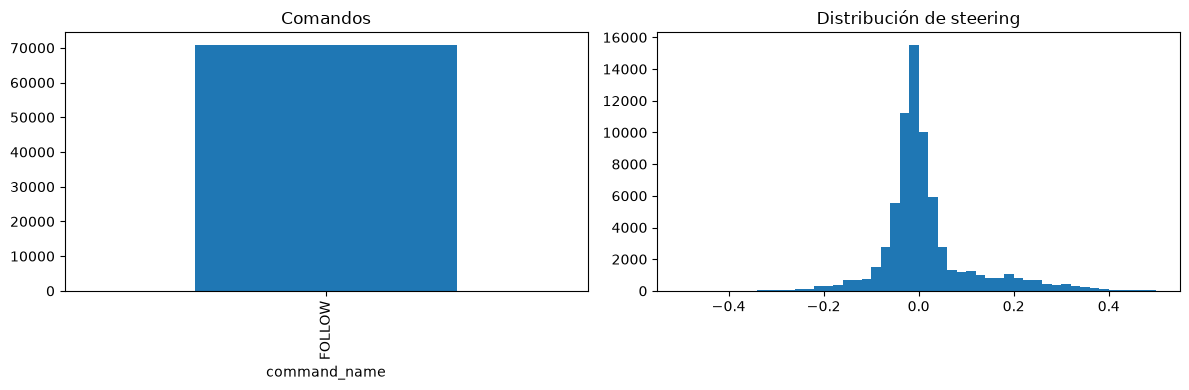

In [3]:
df = pd.read_csv(CSV_PATH)
# Une rutas relativas con la carpeta del dataset.
df["path"] = df["image"].apply(lambda p: os.path.join(DATASET_DIR, p))
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
print("Filas válidas:", len(df))
print(df["command_name"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["command_name"].value_counts().plot(kind="bar", ax=ax[0], title="Comandos")
ax[1].hist(df["steering"], bins=50); ax[1].set_title("Distribución de steering")
plt.tight_layout(); plt.show()

## 4. Preprocesamiento

`preprocess()` debe ser idéntico en entrenamiento y en inferencia. Recibe una
imagen **BGR** (como la entrega OpenCV / la cámara de Webots) y devuelve un
tensor RGB normalizado al tamaño del modelo.

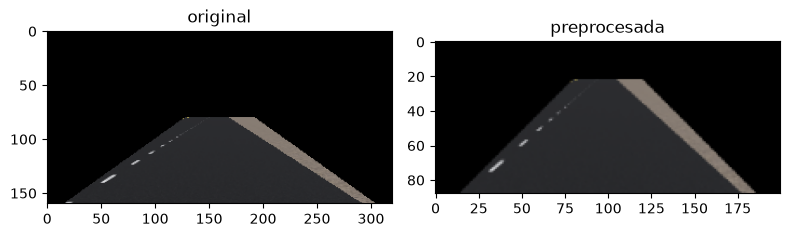

In [4]:
def preprocess(img_bgr):
    """BGR (HxWx3) -> RGB recortada y redimensionada a (IMG_H, IMG_W, 3)."""
    h = img_bgr.shape[0]
    img = img_bgr[CROP_TOP:h - CROP_BOTTOM, :, :]
    img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32)

# Muestra de ejemplo
sample = cv2.imread(df["path"].iloc[0])
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.title("original"); plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2); plt.title("preprocesada"); plt.imshow(preprocess(sample).astype(np.uint8))
plt.tight_layout(); plt.show()

## 5. Data augmentation (flip, brillo, desplazamiento)

In [ ]:
# El dataset fisico YA viene aumentado y balanceado (flip + shift horneados
# offline). En entrenamiento solo agregamos jitter de BRILLO: no toca el steering,
# las etiquetas ni el balance, solo ayuda a generalizar. (Sin flip ni shift aca
# para no augmentar dos veces.)
def augment(img_bgr, steering, command):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] *= random.uniform(0.6, 1.3)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)
    img_bgr = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return img_bgr, steering, command

## 6. Generador de datos con balanceo por comando

In [ ]:
class CILSequence(keras.utils.Sequence):
    """Generador de muestras para CIL.

    El dataset fisico ya viene aumentado (flip/shift horneados). Si BALANCE_CAP
    es un entero, en cada epoca se toman BALANCE_CAP muestras por comando
    (balanceo estilo Codevilla, sobremuestreando giros). Si BALANCE_CAP es None
    (default aqui), se entrena con la distribucion REAL del dataset (FOLLOW-heavy
    44/28/28). En validacion siempre se usa la distribucion real, sin augmentation.
    """
    def __init__(self, frame, batch=BATCH, training=True, **kw):
        super().__init__(**kw)
        self.df = frame.reset_index(drop=True)
        self.batch = batch
        self.training = training
        cmds = self.df["command"].values
        self.groups = {int(c): np.where(cmds == c)[0] for c in np.unique(cmds)}
        self.on_epoch_end()

    def on_epoch_end(self):
        if self.training and BALANCE_CAP is not None:
            # Balanceo por comando: BALANCE_CAP muestras de cada uno por epoca.
            sizes = [len(g) for g in self.groups.values()]
            target = min(max(sizes), BALANCE_CAP)
            parts = [np.random.choice(g, target, replace=len(g) < target)
                     for g in self.groups.values()]
            self.idx = np.concatenate(parts)
            np.random.shuffle(self.idx)
        elif self.training:
            # BALANCE_CAP is None => distribucion REAL del dataset (sin balancear).
            self.idx = np.arange(len(self.df))
            np.random.shuffle(self.idx)
        else:
            self.idx = np.arange(len(self.df))

    def __len__(self):
        return math.ceil(len(self.idx) / self.batch)

    def __getitem__(self, i):
        rows = self.idx[i * self.batch:(i + 1) * self.batch]
        X_img, X_cmd, y = [], [], []
        for r in rows:
            row = self.df.iloc[r]
            img = cv2.imread(row["path"])
            if img is None:
                continue
            steering = float(row["steering"]); command = int(row["command"])
            if self.training:
                img, steering, command = augment(img, steering, command)
            X_img.append(preprocess(img))
            onehot = np.zeros(N_CMD, np.float32); onehot[CMD_INDEX[command]] = 1.0
            X_cmd.append(onehot); y.append(steering)
        return ({"image": np.array(X_img, np.float32),
                 "command": np.array(X_cmd, np.float32)},
                np.array(y, np.float32))

## 7. Split train / val

In [8]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=VAL_SPLIT, random_state=SEED,
                                    stratify=df["command"])
print("train:", len(train_df), "| val:", len(val_df))
train_seq = CILSequence(train_df, training=True)
val_seq   = CILSequence(val_df, training=False)

train: 17000 | val: 3000


## 8. Modelo CIL con una rama (branch) por comando

In [9]:
def build_cil_model():
    img_in = keras.Input(shape=(IMG_H, IMG_W, 3), name="image")
    cmd_in = keras.Input(shape=(N_CMD,), name="command")

    x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(img_in)
    x = layers.Conv2D(24, 5, strides=2, activation="relu")(x)
    x = layers.Conv2D(36, 5, strides=2, activation="relu")(x)
    x = layers.Conv2D(48, 5, strides=2, activation="relu")(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(100, activation="relu")(x)
    x = layers.Dense(50, activation="relu")(x)

    branch_outs = []
    for i in range(N_CMD):
        b = layers.Dense(25, activation="relu", name=f"head_{i}")(x)
        b = layers.Dense(1, name=f"steer_{i}")(b)
        branch_outs.append(b)
    all_branches = layers.Concatenate(name="branches")(branch_outs)   # (None, N_CMD)
    # Producto punto con el one-hot = selecciona la rama del comando activo.
    steer = layers.Dot(axes=1, name="steering")([all_branches, cmd_in])

    model = keras.Model([img_in, cmd_in], steer, name="CIL_branched")
    model.compile(optimizer=keras.optimizers.Adam(LR), loss="mse", metrics=["mae"])
    return model

model = build_cil_model()
model.summary()

Model: "CIL_branched"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 88, 200,   │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 88, 200,   │          0 │ image[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 42, 98,    │      1,824 │ rescaling[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 19, 47,    │     21,636 │ conv2d[0][0]      │
│                     │ 36)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 22, 48) │     43,248 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 6, 20, 64) │     27,712 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 4, 18, 64) │     36,928 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4608)      │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4608)      │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100)       │    460,900 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50)        │      5,050 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_0 (Dense)      │ (None, 25)        │      1,275 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_1 (Dense)      │ (None, 25)        │      1,275 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_2 (Dense)      │ (None, 25)        │      1,275 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steer_0 (Dense)     │ (None, 1)         │         26 │ head_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steer_1 (Dense)     │ (None, 1)         │         26 │ head_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steer_2 (Dense)     │ (None, 1)         │         26 │ head_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branches            │ (None, 3)         │          0 │ steer_0[0][0],    │
│ (Concatenate)       │                   │            │ steer_1[0][0],    │
│                     │                   │            │ steer_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ command             │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ steering (Dot)      │ (None, 1)         │          0 │ branches[0][0],   │
│                     │                   │            │ command[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 601,201 (2.29 MB)

 Trainable params: 601,201 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Entrenamiento

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(OUT_MODEL, monitor="val_loss",
                                    save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=4, min_lr=1e-6, verbose=1),
]
history = model.fit(train_seq, validation_data=val_seq,
                    epochs=EPOCHS, callbacks=callbacks)

Epoch 1/60


I0000 00:00:1782682252.720898  104087 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 0.0167 - mae: 0.0894
Epoch 1: val_loss improved from None to 0.00847, saving model to cil_model.keras

Epoch 1: finished saving model to cil_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 273ms/step - loss: 0.0167 - mae: 0.0894 - val_loss: 0.0085 - val_mae: 0.0447 - learning_rate: 1.0000e-04
Epoch 2/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 0.0149 - mae: 0.0853
Epoch 2: val_loss improved from 0.00847 to 0.00785, saving model to cil_model.keras

Epoch 2: finished saving model to cil_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 103s 274ms/step - loss: 0.0149 - mae: 0.0853 - val_loss: 0.0079 - val_mae: 0.0462 - learning_rate: 1.0000e-04
Epoch 3/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 0.0132 - mae: 0.0801
Epoch 3: val_loss improved from 0.00785 to 0.00756, saving model to cil_model.keras

Epoch 3: finished saving model to cil_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 103s 274ms/step - loss: 0.0132 - mae: 0.0801 - val_lo

## 10. Curvas de aprendizaje

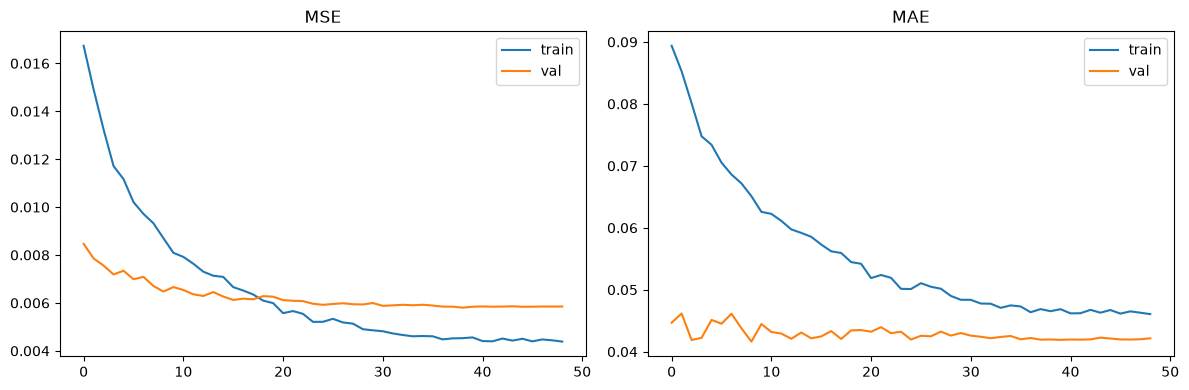

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val"); plt.title("MSE"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val"); plt.title("MAE"); plt.legend()
plt.tight_layout(); plt.show()

## 11. Predicciones de ejemplo (sanity check)

In [12]:
xb, yb = val_seq[0]
pred = model.predict(xb, verbose=0).ravel()
for i in range(min(8, len(yb))):
    cmd = COMMANDS[int(np.argmax(xb["command"][i]))]
    print(f"cmd={cmd}  real={yb[i]:+.3f}  pred={pred[i]:+.3f}")

cmd=2  real=+0.023  pred=-0.024
cmd=2  real=+0.000  pred=+0.022
cmd=3  real=-0.500  pred=-0.460
cmd=2  real=-0.000  pred=-0.006
cmd=4  real=+0.108  pred=+0.182
cmd=3  real=-0.013  pred=-0.035
cmd=2  real=+0.000  pred=+0.007
cmd=2  real=+0.000  pred=+0.013


## 12. Exportar modelo + configuración

El `model_config.json` lleva los parámetros de preprocesamiento para que el
controlador de inferencia (Fase C) reproduzca EXACTAMENTE la misma entrada.

In [13]:
model.save(OUT_MODEL)
config = {
    "crop_top": CROP_TOP, "crop_bottom": CROP_BOTTOM,
    "img_w": IMG_W, "img_h": IMG_H,
    "commands": COMMANDS, "max_steer": MAX_STEER,
}
with open(OUT_CONFIG, "w") as f:
    json.dump(config, f, indent=2)
print("Guardado:", OUT_MODEL, "y", OUT_CONFIG)

Guardado: cil_model.keras y model_config.json
